# Jaw Cutout and Masking (Side Profile)
This notebook isolates a person from the background and automatically applies a perfectly curated mask over the jaw area, designed specifically for pure side profile photos using an advanced geometric face parsing approach.

In [41]:
import cv2
import numpy as np
import torch
from PIL import Image
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [42]:
# Initialize Face Parser
print("Loading Face Parser model...")
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("Model ready!")

Loading Face Parser model...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Model ready!


In [51]:
import tkinter as tk
from tkinter import filedialog

print("Opening file dialog... Please check your taskbar for the popup window.")

root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

file_path = filedialog.askopenfilename(
    title="Select a Side Profile Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
    print("You can now run the next cell!")
else:
    print("No file selected.")


Opening file dialog... Please check your taskbar for the popup window.
Selected file: C:/Users/PratikJPatel/Downloads/new-45-2.jpg
You can now run the next cell!


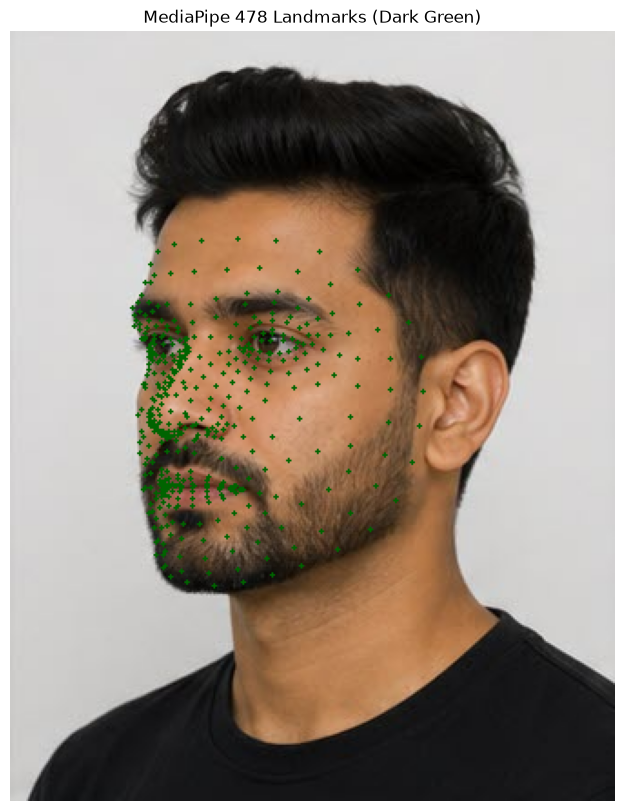

In [54]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import numpy as np

if 'file_path' in locals() and file_path:
    image = cv2.imread(file_path)
    if image is not None:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Initialize FaceLandmarker with modern Tasks API
        base_options = python.BaseOptions(model_asset_path="face_landmarker.task")
        options = vision.FaceLandmarkerOptions(base_options=base_options,
                                              output_face_blendshapes=False,
                                              output_facial_transformation_matrixes=False,
                                              num_faces=1)
        detector = vision.FaceLandmarker.create_from_options(options)
        
        # Process image
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
        detection_result = detector.detect(mp_image)
        
        # Draw landmarks with a darker green color
        annotated_image = image_rgb.copy()
        if detection_result.face_landmarks:
            for face_landmarks in detection_result.face_landmarks:
                for idx, landmark in enumerate(face_landmarks):
                    x = int(landmark.x * image.shape[1])
                    y = int(landmark.y * image.shape[0])
                    # Using a darker green: RGB(0, 100, 0)
                    cv2.circle(annotated_image, (x, y), 1, (0, 100, 0), -1)
                    
            plt.figure(figsize=(10, 10))
            plt.imshow(annotated_image)
            plt.axis('off')
            plt.title("MediaPipe 478 Landmarks (Dark Green)")
            plt.show()
        else:
            print("No face detected by MediaPipe in this image.")


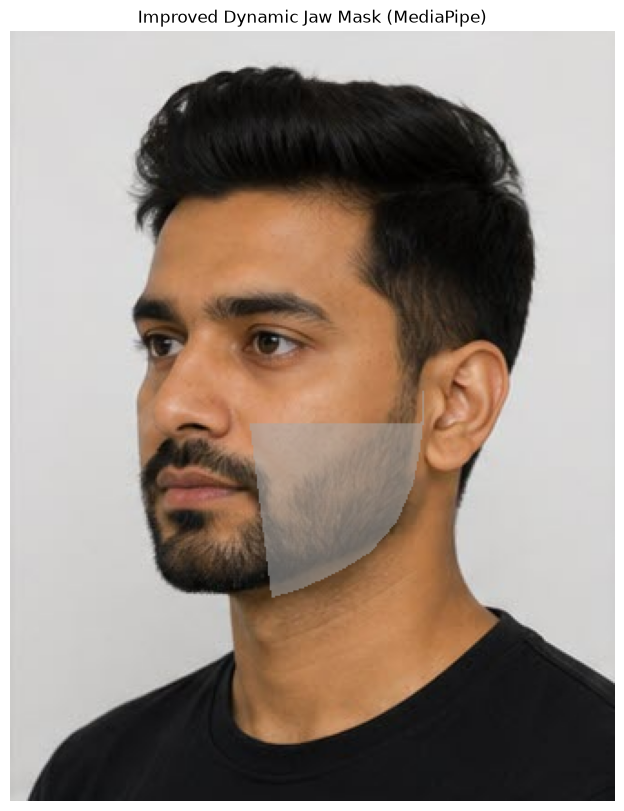

In [55]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import matplotlib.pyplot as plt
import numpy as np

if 'file_path' in locals() and file_path:
    image = cv2.imread(file_path)
    if image is not None:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape
        
        # Initialize FaceLandmarker with modern Tasks API
        base_options = python.BaseOptions(model_asset_path="face_landmarker.task")
        options = vision.FaceLandmarkerOptions(base_options=base_options,
                                              output_face_blendshapes=False,
                                              output_facial_transformation_matrixes=False,
                                              num_faces=1)
        detector = vision.FaceLandmarker.create_from_options(options)
        
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
        detection_result = detector.detect(mp_image)
        
        if detection_result.face_landmarks:
            face_landmarks = detection_result.face_landmarks[0]
            
            # Determine face orientation using 3D Z-coordinates
            left_ear_z = face_landmarks[454].z
            right_ear_z = face_landmarks[234].z
            facing_left = right_ear_z < left_ear_z # Right ear is closer to camera
            
            if facing_left:
                jawline_indices = [234, 93, 132, 58, 172, 136, 150, 149, 176, 148, 152]
                ear_idx = 234
            else:
                jawline_indices = [454, 323, 361, 288, 397, 365, 379, 378, 400, 377, 152]
                ear_idx = 454
                
            nose_tip = face_landmarks[1]
            ear = face_landmarks[ear_idx]
            
            # Convert to pixel coordinates
            nose_x, nose_y = int(nose_tip.x * w), int(nose_tip.y * h)
            ear_x, ear_y = int(ear.x * w), int(ear.y * h)
            
            # Calculate the front boundary (e.g., 65% of the distance from ear to nose)
            # This perfectly mimics the cutoff point of the trapezoid mask
            if facing_left:
                front_x = int(ear_x + 0.65 * (nose_x - ear_x))
            else:
                front_x = int(ear_x - 0.65 * (ear_x - nose_x))
                
            # Build the dynamic polygon
            polygon_pts = []
            
            # 1. Start at top-back corner
            polygon_pts.append([ear_x, nose_y])
            
            # 2. Add top-front corner
            polygon_pts.append([front_x, nose_y])
            
            # 3. Trace the jawline backwards from the front cutoff point to the ear
            jawline_pts = []
            for idx in jawline_indices:
                pt_x = int(face_landmarks[idx].x * w)
                pt_y = int(face_landmarks[idx].y * h)
                
                # Push the jawline down slightly to account for the beard hanging below the jawbone
                # 3% of the image height is a good approximation for beard thickness
                pt_y += int(h * 0.03) 
                
                # Only include points that are behind the front cutoff line
                if (facing_left and pt_x <= front_x) or (not facing_left and pt_x >= front_x):
                    jawline_pts.append([pt_x, pt_y])
            
            # We need to reverse the jawline points so they connect cleanly from front to back
            jawline_pts = jawline_pts[::-1]
            polygon_pts.extend(jawline_pts)
            
            # 4. Close the polygon at the ear
            polygon_pts.append([ear_x, ear_y])
            
            polygon_pts = np.array(polygon_pts, np.int32)
            
            # Create a mask for the polygon
            poly_mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(poly_mask, [polygon_pts], 1)
            
            # Apply the semi-transparent gray overlay
            overlay = image_rgb.copy()
            overlay[poly_mask == 1] = [170, 170, 170]
            
            alpha = 0.55
            final_image = cv2.addWeighted(overlay, alpha, image_rgb, 1 - alpha, 0)
            
            plt.figure(figsize=(10, 10))
            plt.imshow(final_image)
            plt.axis('off')
            plt.title("Improved Dynamic Jaw Mask (MediaPipe)")
            plt.show()
        else:
            print("No face detected by MediaPipe. Please ensure it's a 45-degree or frontal image!")
